In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import duckdb

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
df_customers = pd.read_csv("/content/drive/MyDrive/olist_customers_dataset.csv")
df_order_payments = pd.read_csv("/content/drive/MyDrive/olist_order_payments_dataset.csv")
df_orders = pd.read_csv("/content/drive/MyDrive/olist_orders_dataset.csv")
df_order_reviews = pd.read_csv("/content/drive/MyDrive/olist_order_reviews_dataset.csv")
df_products = pd.read_csv("/content/drive/MyDrive/olist_products_dataset.csv")
df_geolocation = pd.read_csv("/content/drive/MyDrive/olist_geolocation_dataset.csv")
df_order_items = pd.read_csv("/content/drive/MyDrive/olist_order_items_dataset.csv")
df_sellers = pd.read_csv("/content/drive/MyDrive/sellers.csv")



Pergunta Norteadora
“Quais fatores mais influenciam a satisfação do cliente no e-commerce e como a empresa pode atuar sobre eles para melhorar a experiência e aumentar a fidelização?”
Para explorar a pergunta norteadora vamos trabalhar com 4 de variáveis:



*   Categoria do Produto: [product_category_name], disponível na base olist_products_dataset
*   Dias de atraso na entrega: Vamos criar a variável [dias_atraso_entrega] = max(0,[order_delivered_customer_date] - [order_estimated_delivery_date]), disponíveis em olist_orders_dataset
*   Valor total da compra: que vai ser a soma dos itens comprados [preco_tota_item] = [price] + [freight_value]obs. Optamos por não utilizar o valor total da compra para manter a granularidade da tabela no nível de item
*   Valor do frete: [frete_total] = order_items.groupby("order_id")["freight_value"].sum() disponível na olist_order_items_dataset

Pretendemos descobrir o impacto que essas variáveis possuem em 2 dimensões:

*   Experiência do cliente: Vamos considerar com base na avaliação [review_score], disponível na base olist_order_reviews_dataset
*   Fidelização: Vamos considerar a recompra de um mesmo cliente em um mesmo vendedor, para isso vamos criar uma variável binária [cliente_recomprou_mesmo_vendedor] que verifica se um cliente [customer_id], na base olist_orders_dataset, fez mais de uma compra em um mesmo vendedor [seller_id], na base olist_order_items_dataset

No final da análise pretendemos avaliar a relação das 4 variáveis explicativas com o impacto nas 2 variáveis de resultado para responder quais fatores operacionais devem ser priorizados pelos vendedores para maximizar a satisfação e a probabilidade de recompra.







In [4]:
datasets = {
    "df_customers": df_customers,
    "df_orders": df_orders,
    "df_order_items": df_order_items,
    "df_order_payments": df_order_payments,
    "df_order_reviews": df_order_reviews,
    "df_products": df_products

}

for name, df in datasets.items():
  print(name, df.shape)

df_customers (99441, 5)
df_orders (99441, 8)
df_order_items (112650, 7)
df_order_payments (103886, 5)
df_order_reviews (99224, 7)
df_products (32951, 9)


*Tabela produtos*

In [5]:
df_products

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0
...,...,...,...,...,...,...,...,...,...
32946,a0b7d5a992ccda646f2d34e418fff5a0,moveis_decoracao,45.0,67.0,2.0,12300.0,40.0,40.0,40.0
32947,bf4538d88321d0fd4412a93c974510e6,construcao_ferramentas_iluminacao,41.0,971.0,1.0,1700.0,16.0,19.0,16.0
32948,9a7c6041fa9592d9d9ef6cfe62a71f8c,cama_mesa_banho,50.0,799.0,1.0,1400.0,27.0,7.0,27.0
32949,83808703fc0706a22e264b9d75f04a2e,informatica_acessorios,60.0,156.0,2.0,700.0,31.0,13.0,20.0


In [6]:
df_products["product_category_name"].unique()

array(['perfumaria', 'artes', 'esporte_lazer', 'bebes',
       'utilidades_domesticas', 'instrumentos_musicais', 'cool_stuff',
       'moveis_decoracao', 'eletrodomesticos', 'brinquedos',
       'cama_mesa_banho', 'construcao_ferramentas_seguranca',
       'informatica_acessorios', 'beleza_saude', 'malas_acessorios',
       'ferramentas_jardim', 'moveis_escritorio', 'automotivo',
       'eletronicos', 'fashion_calcados', 'telefonia', 'papelaria',
       'fashion_bolsas_e_acessorios', 'pcs', 'casa_construcao',
       'relogios_presentes', 'construcao_ferramentas_construcao',
       'pet_shop', 'eletroportateis', 'agro_industria_e_comercio', nan,
       'moveis_sala', 'sinalizacao_e_seguranca', 'climatizacao',
       'consoles_games', 'livros_interesse_geral',
       'construcao_ferramentas_ferramentas',
       'fashion_underwear_e_moda_praia', 'fashion_roupa_masculina',
       'moveis_cozinha_area_de_servico_jantar_e_jardim',
       'industria_comercio_e_negocios', 'telefonia_fixa',
   

In [7]:
df_products["product_category_name"].nunique(dropna=True)

73

In [8]:
# Comparando a nota média de avaliação de acordo com a categoria de produto

query_categoria_produtos = """
SELECT
    p.product_category_name,
    AVG(rv.review_score) AS nota_media
FROM df_products AS p
JOIN df_order_items AS oi
    ON p.product_id = oi.product_id
JOIN df_order_reviews AS rv
    ON rv.order_id = oi.order_id
  GROUP BY p.product_category_name
ORDER BY nota_media DESC
"""
categoria = duckdb.query(query_categoria_produtos).to_df()
categoria

,product_category_name,nota_media
0,cds_dvds_musicais,4.642857
1,fashion_roupa_infanto_juvenil,4.500000
2,livros_interesse_geral,4.446266
3,construcao_ferramentas_ferramentas,4.444444
4,flores,4.419355
...,...,...
69,moveis_escritorio,3.493183
70,pc_gamer,3.333333
71,portateis_cozinha_e_preparadores_de_alimentos,3.266667
72,fraldas_higiene,3.256410


In [9]:
# Treinando o código tb em python

categoria_produtos_python = (
    df_products.merge(
        df_order_items[["product_id", "order_id"]],
        on="product_id",
        how="left"
        ).merge(
            df_order_reviews[["order_id", "review_score"]],
            on="order_id",
            how="left"
        )
        .groupby("product_category_name")["review_score"]
        .mean()
        .sort_values(ascending=False)
        .reset_index(name="nota_media")

    )




In [10]:
top10 = (
    categoria_produtos_python
    .groupby("product_category_name")["nota_media"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

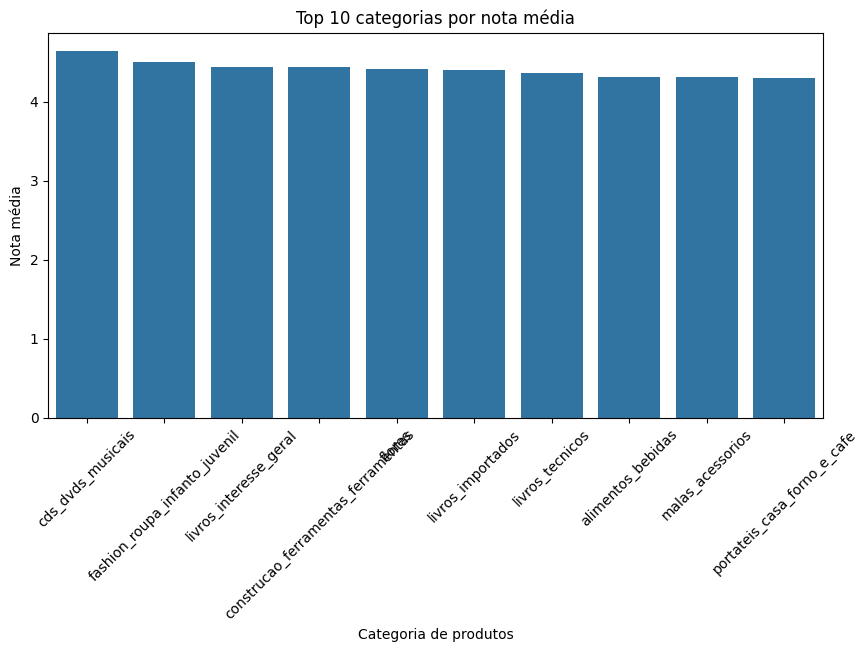

In [11]:
plt.figure(figsize=(10,5))

sns.barplot(
    x=top10.index,
    y=top10.values
)

plt.title("Top 10 categorias por nota média")
plt.xlabel("Categoria de produtos")
plt.ylabel("Nota média")
plt.xticks(rotation=45)

plt.show()

In [12]:
top10 = categoria.groupby("product_category_name")["nota_media"] \
                 .mean() \
                 .sort_values(ascending=False) \
                 .head(10)


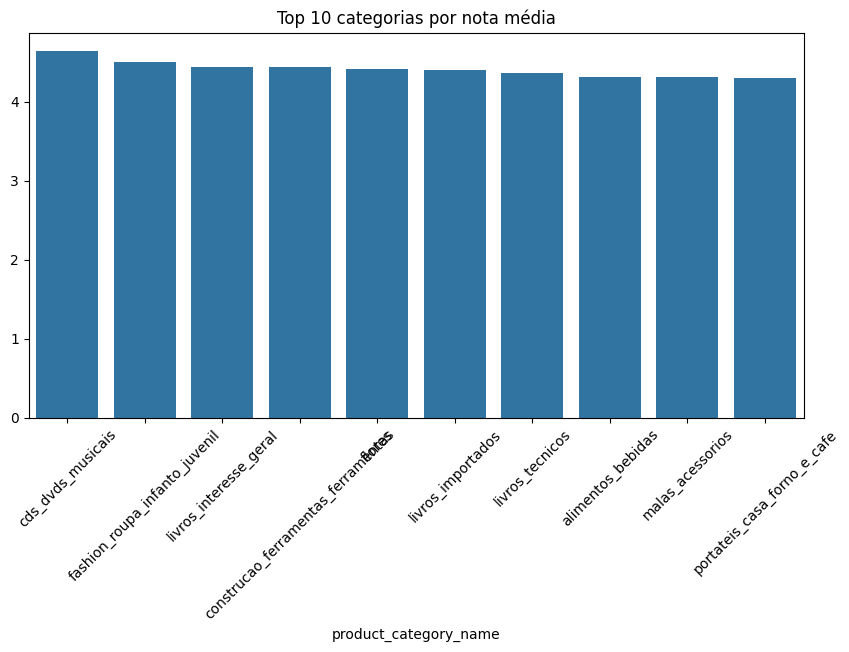

In [13]:
plt.figure(figsize=(10,5))

sns.barplot(
    x=top10.index,
    y=top10.values
)

plt.title("Top 10 categorias por nota média")
plt.xticks(rotation=45)
plt.show()

*Tabela pagamentos*

In [14]:
df_order_payments

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45
...,...,...,...,...,...
103881,0406037ad97740d563a178ecc7a2075c,1,boleto,1,363.31
103882,7b905861d7c825891d6347454ea7863f,1,credit_card,2,96.80
103883,32609bbb3dd69b3c066a6860554a77bf,1,credit_card,1,47.77
103884,b8b61059626efa996a60be9bb9320e10,1,credit_card,5,369.54


In [15]:
df_order_payments = df_order_payments.dropna()

In [16]:
df_order_payments = df_order_payments.drop_duplicates()

*Método de pagamento mais usado*

In [17]:
df_metodo_pagamento_mais_usado = df_order_payments.payment_type.value_counts()
df_metodo_pagamento_mais_usado

,count
payment_type,
credit_card,76795
boleto,19784
voucher,5775
debit_card,1529
not_defined,3


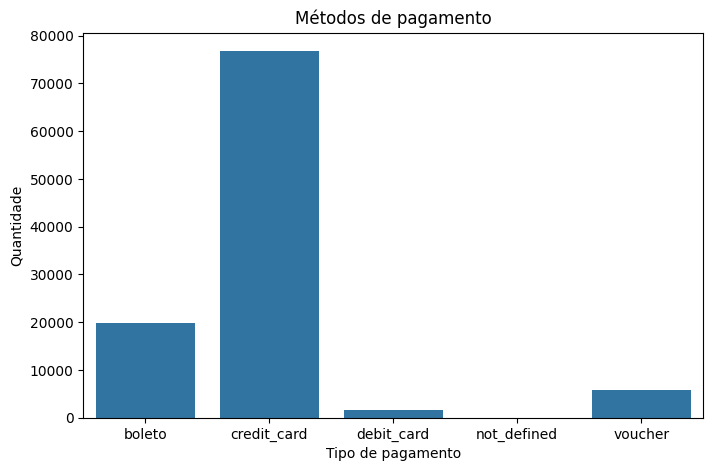

In [18]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df_order_payments,
    x="payment_type",
    order=sorted(df_order_payments["payment_type"].unique())
)

plt.title("Métodos de pagamento")
plt.xlabel("Tipo de pagamento")
plt.ylabel("Quantidade")

plt.show()

*Valor médio da compra de acordo com o meio de pagamento*

In [19]:
df_valor_medio_compra = df_order_payments.groupby("payment_type")["payment_value"].mean()
df_valor_medio_compra

,payment_value
payment_type,
boleto,145.034435
credit_card,163.319021
debit_card,142.570170
not_defined,0.000000
voucher,65.703354


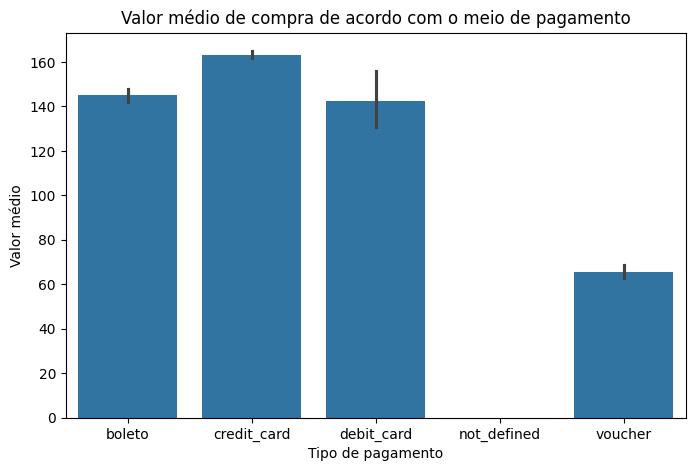

In [20]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df_order_payments,
    x="payment_type",
    y="payment_value",
    order=sorted(df_order_payments["payment_type"].unique())
)

plt.title("Valor médio de compra de acordo com o meio de pagamento")
plt.xlabel("Tipo de pagamento")
plt.ylabel("Valor médio")
plt.show()

*Tabela de pedidos*

In [21]:

df_orders

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00
...,...,...,...,...,...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28 00:00:00
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02 00:00:00
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27 00:00:00
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 00:00:00


In [22]:
df_copia = df_orders.copy()

*Mudando o tipo de dado de object para datetime*

In [23]:
coluna_datas = ["order_purchase_timestamp", "order_approved_at", "order_delivered_carrier_date", "order_delivered_customer_date", "order_estimated_delivery_date"]

In [24]:
df_orders[coluna_datas] = df_orders[coluna_datas].apply(
    pd.to_datetime
)
df_orders

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26
...,...,...,...,...,...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15


*Lead time entre compra, aprovação, postagem e entrega*

*1.Tempo entre compra e aprovação: quanto tempo (em dias) o pagamento demora a ser aprovado.*

In [25]:
lead_time_pagamento = (
    df_orders["order_approved_at"] - df_orders["order_purchase_timestamp"]
).dt.days
lead_time_pagamento

,0
0,0.0
1,1.0
2,0.0
3,0.0
4,0.0
...,...
99436,0.0
99437,0.0
99438,0.0
99439,0.0


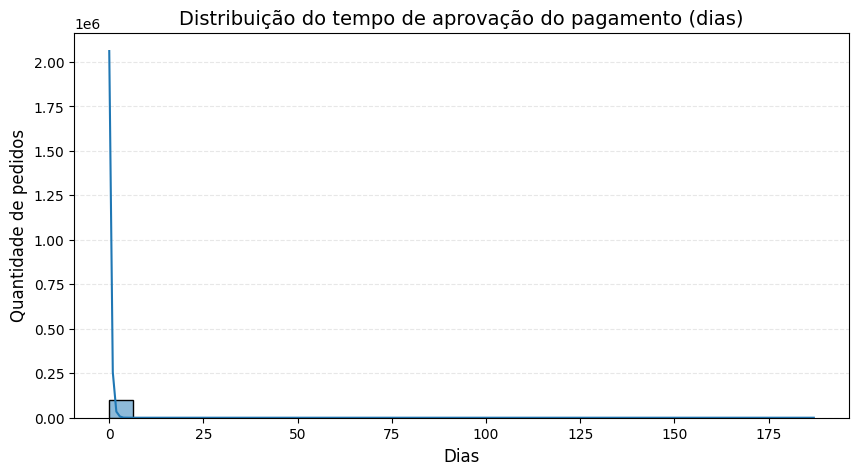

In [26]:
plt.figure(figsize=(10, 5))

sns.histplot(
    lead_time_pagamento,
    bins=30,
    kde=True  # adiciona curva de densidade
)

plt.title("Distribuição do tempo de aprovação do pagamento (dias)", fontsize=14)
plt.xlabel("Dias", fontsize=12)
plt.ylabel("Quantidade de pedidos", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.show()

In [27]:
percentual_mesmo_dia = (lead_time_pagamento == 0).mean() * 100

print(f"{percentual_mesmo_dia:.2f}% dos pagamentos são aprovados no mesmo dia")

82.32% dos pagamentos são aprovados no mesmo dia


*2. Lead time de processamento do vendedor: quanto tempo o vendedor demora para despachar o produto.*

In [28]:
lead_time_envio = (
    df_orders["order_delivered_carrier_date"] - df_orders["order_approved_at"]
).dt.days
lead_time_envio

,0
0,2.0
1,0.0
2,0.0
3,3.0
4,0.0
...,...
99436,1.0
99437,1.0
99438,1.0
99439,3.0


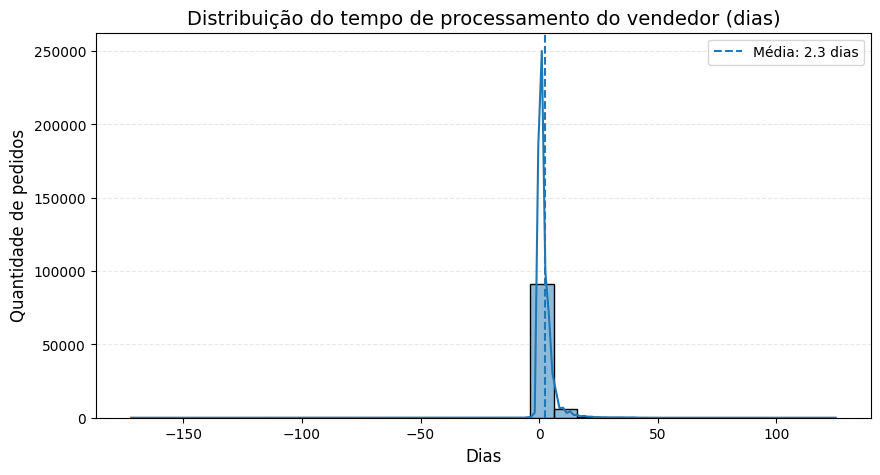

In [29]:
plt.figure(figsize=(10, 5))

sns.histplot(
    lead_time_envio,
    bins=30,
    kde=True
)

plt.title("Distribuição do tempo de processamento do vendedor (dias)", fontsize=14)
plt.xlabel("Dias", fontsize=12)
plt.ylabel("Quantidade de pedidos", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.axvline(
    lead_time_envio.mean(),
    linestyle="--",
    label=f"Média: {lead_time_envio.mean():.1f} dias"
)

plt.legend()
plt.show()

In [30]:
media_dias_despacho_vendedor = (lead_time_envio).mean()
print(f'Os vendedores levam em méda {media_dias_despacho_vendedor:.2f} dias para despachar o produto.')

Os vendedores levam em méda 2.30 dias para despachar o produto.


*3. Lead time de transporte: quanto tempo a transportadora leva para entregar.*

In [31]:
lead_time_transporte = (
    df_orders["order_delivered_customer_date"] - df_orders["order_delivered_carrier_date"]
).dt.days
lead_time_transporte

,0
0,6.0
1,12.0
2,9.0
3,9.0
4,1.0
...,...
99436,7.0
99437,20.0
99438,23.0
99439,13.0


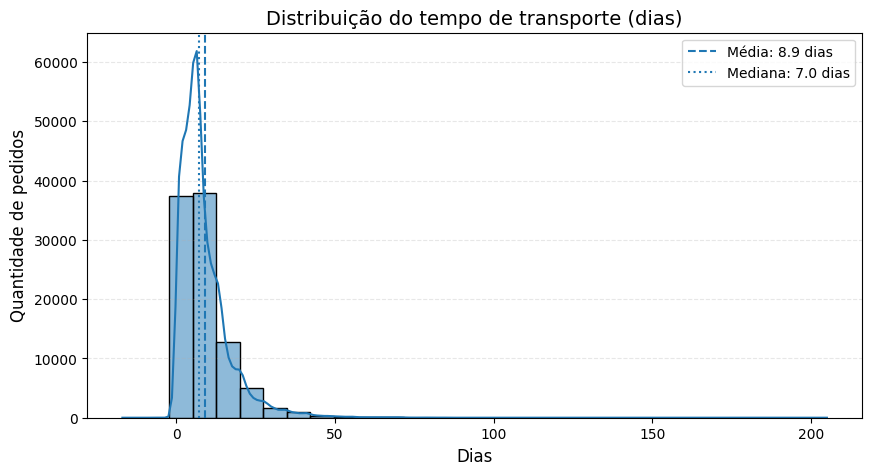

In [32]:
plt.figure(figsize=(10, 5))

sns.histplot(
    lead_time_transporte,
    bins=30,
    kde=True
)

plt.title("Distribuição do tempo de transporte (dias)", fontsize=14)
plt.xlabel("Dias", fontsize=12)
plt.ylabel("Quantidade de pedidos", fontsize=12)

plt.axvline(
    lead_time_transporte.mean(),
    linestyle="--",
    label=f"Média: {lead_time_transporte.mean():.1f} dias"
)

plt.axvline(
    lead_time_transporte.median(),
    linestyle=":",
    label=f"Mediana: {lead_time_transporte.median():.1f} dias"
)

plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.legend()

plt.show()

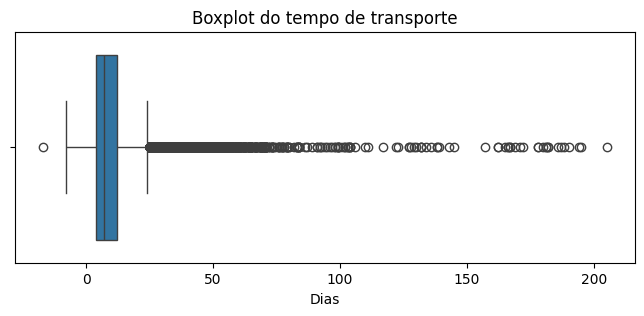

In [33]:
plt.figure(figsize=(8, 3))

sns.boxplot(x=lead_time_transporte)

plt.title("Boxplot do tempo de transporte")
plt.xlabel("Dias")
plt.show()

In [34]:
media_dias_entrega_transportadora = (lead_time_transporte).mean()
print(f'O tempo médio de entrega é: {media_dias_entrega_transportadora:.2f} dias')

O tempo médio de entrega é: 8.88 dias


*4. Lead time total do pedido: tempo total entre compra e entrega*

In [35]:
df_lead_time_total = (
    df_orders["order_delivered_customer_date"] - df_orders["order_purchase_timestamp"]
).dt.days
df_lead_time_total

,0
0,8.0
1,13.0
2,9.0
3,13.0
4,2.0
...,...
99436,8.0
99437,22.0
99438,24.0
99439,17.0


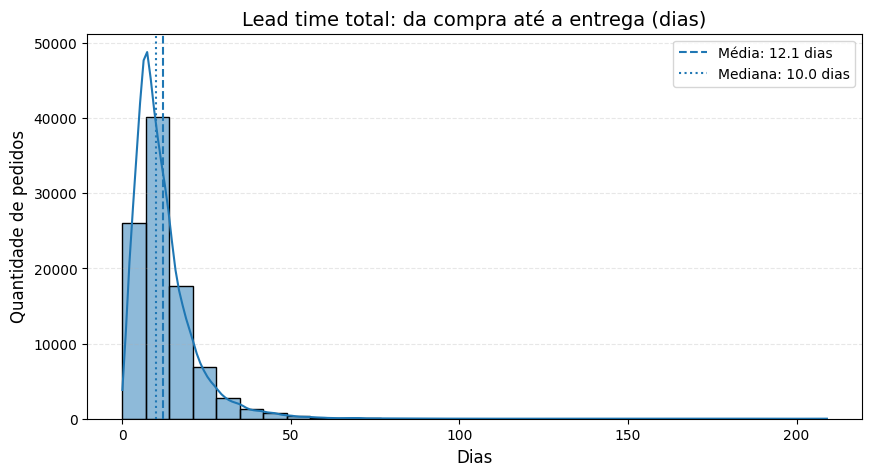

In [36]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df_lead_time_total,
    bins=30,
    kde=True
)

plt.title("Lead time total: da compra até a entrega (dias)", fontsize=14)
plt.xlabel("Dias", fontsize=12)
plt.ylabel("Quantidade de pedidos", fontsize=12)

plt.axvline(
    df_lead_time_total.mean(),
    linestyle="--",
    label=f"Média: {df_lead_time_total.mean():.1f} dias"
)

plt.axvline(
    df_lead_time_total.median(),
    linestyle=":",
    label=f"Mediana: {df_lead_time_total.median():.1f} dias"
)

plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.legend()

plt.show()

In [37]:
media_tempo_total = (df_lead_time_total).mean()
print(f'O tempo médio total entre a data da compra e a entrega é: {media_tempo_total:.2f} dias')

O tempo médio total entre a data da compra e a entrega é: 12.09 dias


In [38]:
df_orders["atraso"] = np.where(
    df_orders["order_delivered_customer_date"] >
    df_orders["order_estimated_delivery_date"],
    "Sim",
    "Não"
  )


In [39]:
df_orders["dias_de_atraso"] = (
  df_orders["order_delivered_customer_date"] -
  df_orders["order_estimated_delivery_date"]
).dt.days.clip(lower=0)


In [40]:
df_orders["dias_de_atraso"].mean()

np.float64(0.7193913512168829)

In [41]:
df_orders

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,atraso,dias_de_atraso
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,Não,0.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,Não,0.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,Não,0.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,Não,0.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,Não,0.0
...,...,...,...,...,...,...,...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28,Não,0.0
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02,Não,0.0
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27,Não,0.0
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15,Não,0.0


In [42]:
df_atrasos = df_orders.atraso.value_counts()
df_atrasos

,count
atraso,
Não,91614
Sim,7827


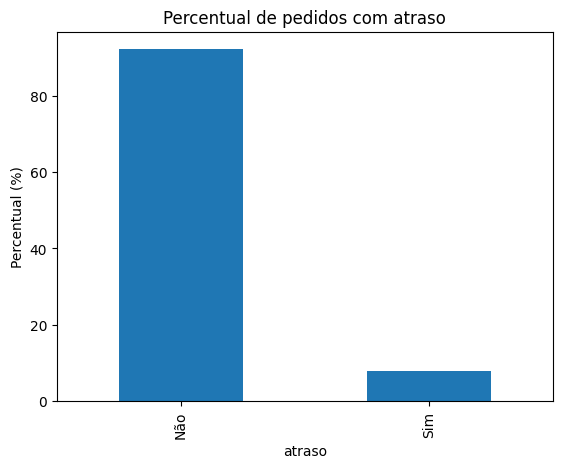

In [43]:
df_atrasos_pct = df_orders.atraso.value_counts(normalize=True) * 100
df_atrasos_pct.plot(kind="bar")

plt.title("Percentual de pedidos com atraso")
plt.ylabel("Percentual (%)")

plt.show()

*Tabela de avaliações*

In [45]:
df_copy2 = df_order_reviews.copy()

In [46]:
df_order_reviews = df_orders.merge(
    df_order_reviews[["order_id", "review_score"]],
    on="order_id",
    how="left"
)
df_order_reviews


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,atraso,dias_de_atraso,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,Não,0.0,4.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,Não,0.0,4.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,Não,0.0,5.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,Não,0.0,5.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,Não,0.0,5.0
...,...,...,...,...,...,...,...,...,...,...,...
99987,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28,Não,0.0,5.0
99988,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02,Não,0.0,4.0
99989,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27,Não,0.0,5.0
99990,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15,Não,0.0,2.0


In [47]:
df_orders

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,atraso,dias_de_atraso
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,Não,0.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,Não,0.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,Não,0.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,Não,0.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,Não,0.0
...,...,...,...,...,...,...,...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28,Não,0.0
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02,Não,0.0
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27,Não,0.0
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15,Não,0.0


In [49]:
df_orders["delivery_time_days"] = (df_orders["order_delivered_customer_date"] - df_orders["order_purchase_timestamp"]).dt.days

In [50]:
df_orders

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,atraso,dias_de_atraso,delivery_time_days
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,Não,0.0,8.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,Não,0.0,13.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,Não,0.0,9.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,Não,0.0,13.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,Não,0.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28,Não,0.0,8.0
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02,Não,0.0,22.0
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27,Não,0.0,24.0
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15,Não,0.0,17.0


*Correlação entre atrasos e review_score*

In [52]:
df_order_reviews.groupby("atraso")["review_score"].mean()


,review_score
atraso,
Não,4.214307
Sim,2.566550


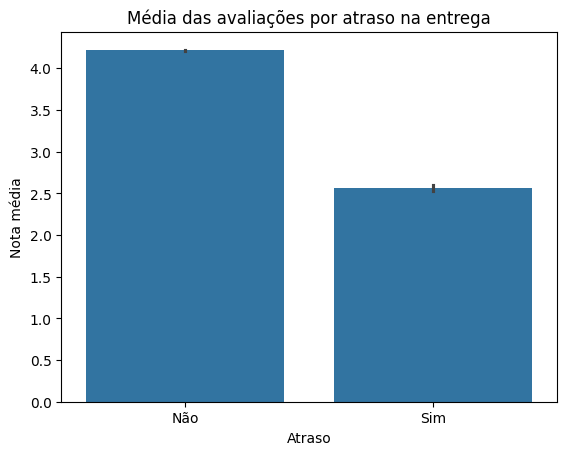

In [53]:
sns.barplot(
    data=df_order_reviews,
    x="atraso",
    y="review_score"
)

plt.title("Média das avaliações por atraso na entrega")
plt.xlabel("Atraso")
plt.ylabel("Nota média")

plt.show()

<Axes: xlabel='atraso', ylabel='review_score'>

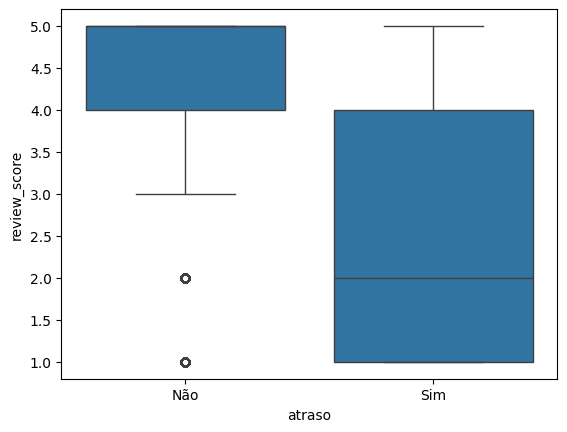

In [74]:
sns.boxplot(
    data=df_order_reviews,
    x="atraso",
    y="review_score"
)

*Tabela clientes*

In [54]:
df_customers

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP
...,...,...,...,...,...
99436,17ddf5dd5d51696bb3d7c6291687be6f,1a29b476fee25c95fbafc67c5ac95cf8,3937,sao paulo,SP
99437,e7b71a9017aa05c9a7fd292d714858e8,d52a67c98be1cf6a5c84435bd38d095d,6764,taboao da serra,SP
99438,5e28dfe12db7fb50a4b2f691faecea5e,e9f50caf99f032f0bf3c55141f019d99,60115,fortaleza,CE
99439,56b18e2166679b8a959d72dd06da27f9,73c2643a0a458b49f58cea58833b192e,92120,canoas,RS


In [55]:

query_recompra = """
SELECT
  COUNT(*) FILTER (WHERE total_pedidos > 1) * 100.0 / COUNT(*) AS taxa_recompra
FROM (
  SELECT
    cs.customer_unique_id,
    COUNT(o.order_id) AS total_pedidos
  FROM df_customers cs
  JOIN df_orders o
    ON cs.customer_id = o.customer_id
  GROUP BY cs.customer_unique_id
)

"""

taxa_recompra = duckdb.query(query_recompra).to_df()
taxa_recompra

,taxa_recompra
0,3.118756


In [56]:
recompra_python = (
    df_customers.merge(
        df_orders[["customer_id", "order_id"]],
        on="customer_id",
        how="left"
    )
    .groupby("customer_unique_id")["order_id"]
    .count()
    .reset_index(name="total_pedidos")
    .query("total_pedidos > 1")
    .shape[0] * 100 / df_customers["customer_unique_id"].nunique()
)

recompra_python

3.118756243756244

A cada 100 clientes aproximadamente 3 voltaram a comprar

In [57]:
recompra_dois = (
    df_customers
    .merge(df_orders, on="customer_id")
    .groupby("customer_unique_id")["order_id"]
    .count()
)

taxa = (recompra_dois > 1).mean() * 100
taxa

np.float64(3.1187562437562435)

In [58]:
query_qtde_pedidos = """
  SELECT
    cs.customer_unique_id,
    COUNT(o.order_id) AS total_pedidos
  FROM df_customers cs
  JOIN df_orders o
    ON cs.customer_id = o.customer_id
  GROUP BY cs.customer_unique_id
  ORDER BY total_pedidos DESC
  """

qtde_pedidos = duckdb.query(query_qtde_pedidos).to_df()
qtde_pedidos


,customer_unique_id,total_pedidos
0,8d50f5eadf50201ccdcedfb9e2ac8455,17
1,3e43e6105506432c953e165fb2acf44c,9
2,6469f99c1f9dfae7733b25662e7f1782,7
3,1b6c7548a2a1f9037c1fd3ddfed95f33,7
4,ca77025e7201e3b30c44b472ff346268,7
...,...,...
96091,82d46759af0369aad49084bacf85a6c3,1
96092,d111b06b6f3a2add0d2241325f65b5ca,1
96093,1a29b476fee25c95fbafc67c5ac95cf8,1
96094,d52a67c98be1cf6a5c84435bd38d095d,1


In [59]:
qtde_pedidos_python = (
    df_customers.merge(
        df_orders[["customer_id", "order_id"]],
        on="customer_id",
        how="left"
    )
    .groupby("customer_unique_id")["order_id"]
    .count()
    .sort_values(ascending=False)
    .reset_index(name="total_pedidos")
)
qtde_pedidos_python

,customer_unique_id,total_pedidos
0,8d50f5eadf50201ccdcedfb9e2ac8455,17
1,3e43e6105506432c953e165fb2acf44c,9
2,6469f99c1f9dfae7733b25662e7f1782,7
3,1b6c7548a2a1f9037c1fd3ddfed95f33,7
4,ca77025e7201e3b30c44b472ff346268,7
...,...,...
96091,5656a8fabc8629ff96b2bc14f8c09a27,1
96092,56560124a5cc70119deb685775639ea7,1
96093,5655ee330a79bd1fd1e5fb220c2436dd,1
96094,5655967ad654dc2d2affca3502631db7,1


In [60]:
query_estado = """
SELECT
  cs.customer_state,
  COUNT(o.order_id) AS total_pedidos
FROM df_customers AS cs
JOIN df_orders AS o
  ON cs.customer_id = o.customer_id
GROUP BY cs.customer_state
ORDER BY total_pedidos DESC
"""

estado = duckdb.query(query_estado).to_df()
estado


,customer_state,total_pedidos
0,SP,41746
1,RJ,12852
2,MG,11635
3,RS,5466
4,PR,5045
5,SC,3637
6,BA,3380
7,DF,2140
8,ES,2033
9,GO,2020


In [61]:
estado_python = (
    df_customers.merge(
        df_orders[["order_id", "customer_id"]],
        on="customer_id",
        how="left"
    )
    .groupby("customer_state")["order_id"]
    .count()
    .sort_values(ascending=False)
    .reset_index(name="total_pedidos")
)
estado_python

,customer_state,total_pedidos
0,SP,41746
1,RJ,12852
2,MG,11635
3,RS,5466
4,PR,5045
5,SC,3637
6,BA,3380
7,DF,2140
8,ES,2033
9,GO,2020


*Correlação entre nota média e região*

In [62]:
query_regiao_avaliacao = """
SELECT cs.customer_state,
  AVG(rv.review_score) AS nota_media
FROM df_customers cs
JOIN df_orders o
  ON cs.customer_id = o.customer_id
JOIN df_order_reviews rv
  ON rv.order_id = o.order_id
GROUP BY cs.customer_state
ORDER BY nota_media DESC
"""

regiao_avaliacao = duckdb.query(query_regiao_avaliacao).to_df()
regiao_avaliacao


,customer_state,nota_media
0,AP,4.194030
1,AM,4.183673
2,PR,4.180032
3,SP,4.173951
4,MG,4.136172
5,RS,4.133321
6,MS,4.118785
7,RN,4.105809
8,MT,4.102990
9,TO,4.096774


In [63]:
regiao_avaliacao_python = (
    df_customers.merge(
        df_orders[["customer_id", "order_id"]],
        on="customer_id",
        how="left"
    ).merge(
        df_order_reviews[["order_id", "review_score"]],
        on="order_id",
        how="left"
    )
    .groupby("customer_state")["review_score"]
    .mean()
    .reset_index()
    .sort_values("review_score", ascending=False)
)
regiao_avaliacao_python

,customer_state,review_score
3,AP,4.194030
2,AM,4.183673
17,PR,4.180032
25,SP,4.173951
10,MG,4.136172
22,RS,4.133321
11,MS,4.118785
19,RN,4.105809
12,MT,4.102990
26,TO,4.096774


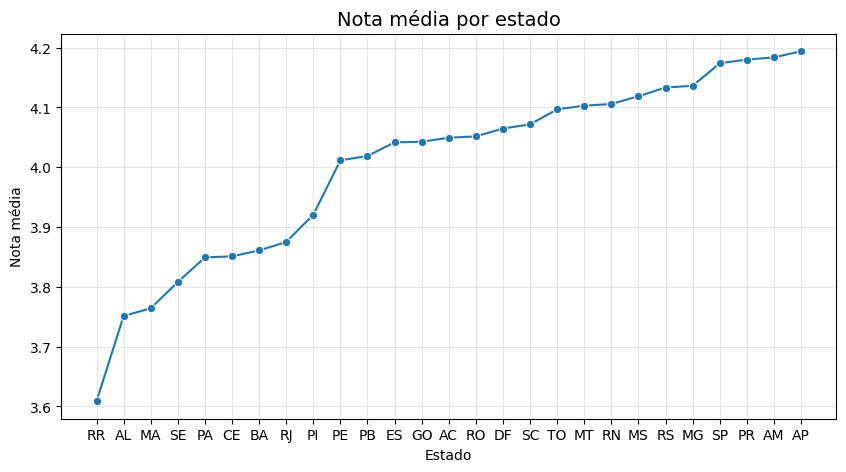

In [77]:
plt.figure(figsize=(10, 5))

sns.lineplot(
    data=regiao_avaliacao.sort_values("nota_media"),
    x="customer_state",
    y="nota_media",
    marker="o"
)

plt.title("Nota média por estado", fontsize=14)
plt.xlabel("Estado")
plt.ylabel("Nota média")
plt.grid(alpha=0.3)

plt.show()

*Tabela itens do pedido*


In [69]:
df_order_items

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14
...,...,...,...,...,...,...,...
112645,fffc94f6ce00a00581880bf54a75a037,1,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-05-02 04:11:01,299.99,43.41
112646,fffcd46ef2263f404302a634eb57f7eb,1,32e07fd915822b0765e448c4dd74c828,f3c38ab652836d21de61fb8314b69182,2018-07-20 04:31:48,350.00,36.53
112647,fffce4705a9662cd70adb13d4a31832d,1,72a30483855e2eafc67aee5dc2560482,c3cfdc648177fdbbbb35635a37472c53,2017-10-30 17:14:25,99.90,16.95
112648,fffe18544ffabc95dfada21779c9644f,1,9c422a519119dcad7575db5af1ba540e,2b3e4a2a3ea8e01938cabda2a3e5cc79,2017-08-21 00:04:32,55.99,8.72


In [70]:
frete_total = df_order_items.groupby("order_id")["freight_value"].sum()
frete_total

,freight_value
order_id,
00010242fe8c5a6d1ba2dd792cb16214,13.29
00018f77f2f0320c557190d7a144bdd3,19.93
000229ec398224ef6ca0657da4fc703e,17.87
00024acbcdf0a6daa1e931b038114c75,12.79
00042b26cf59d7ce69dfabb4e55b4fd9,18.14
...,...
fffc94f6ce00a00581880bf54a75a037,43.41
fffcd46ef2263f404302a634eb57f7eb,36.53
fffce4705a9662cd70adb13d4a31832d,16.95
